In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

In [3]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [4]:
df=pd.read_excel("data.xlsx")

df=df[df['judgementyear'] != 2025]

df_zhuanjiyin=df[df['istransgenosis']==1]

df=df[df['judgementregion']!='国家']

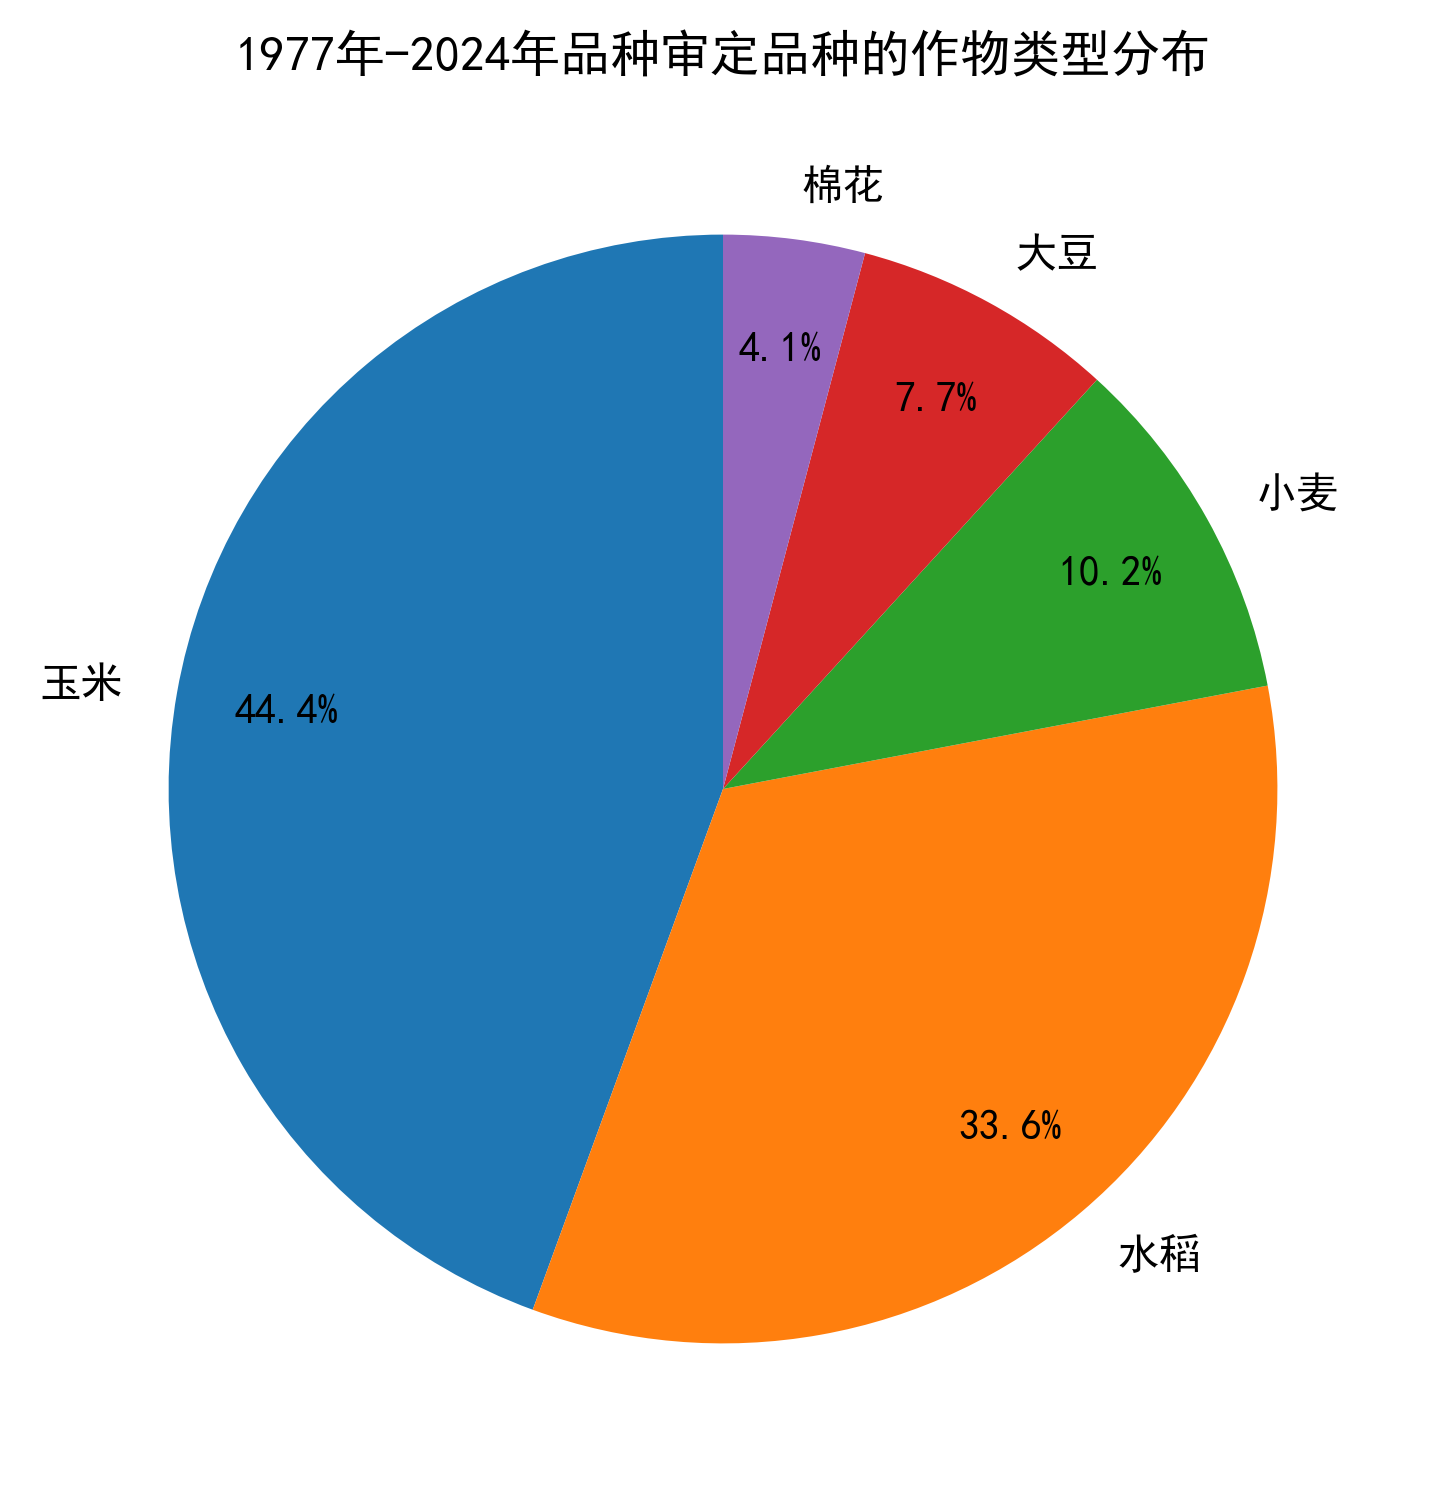

In [5]:
# 作物分布饼图
plt.figure(figsize=(6,6),dpi=300)

# 作饼图，df['cropname'].value_counts()返回的是该列中每个唯一值的出现次数，按从高到低排序
# 索引：唯一值（这里是作物名称 '水稻', '玉米', '小麦'），值：对应的出现次数
df['cropname'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8
)

# 设置标题
plt.title("1977年-2024年品种审定品种的作物类型分布")

plt.ylabel("")

plt.savefig('作物分布饼图',dpi=300,bbox_inches='tight')
plt.show()

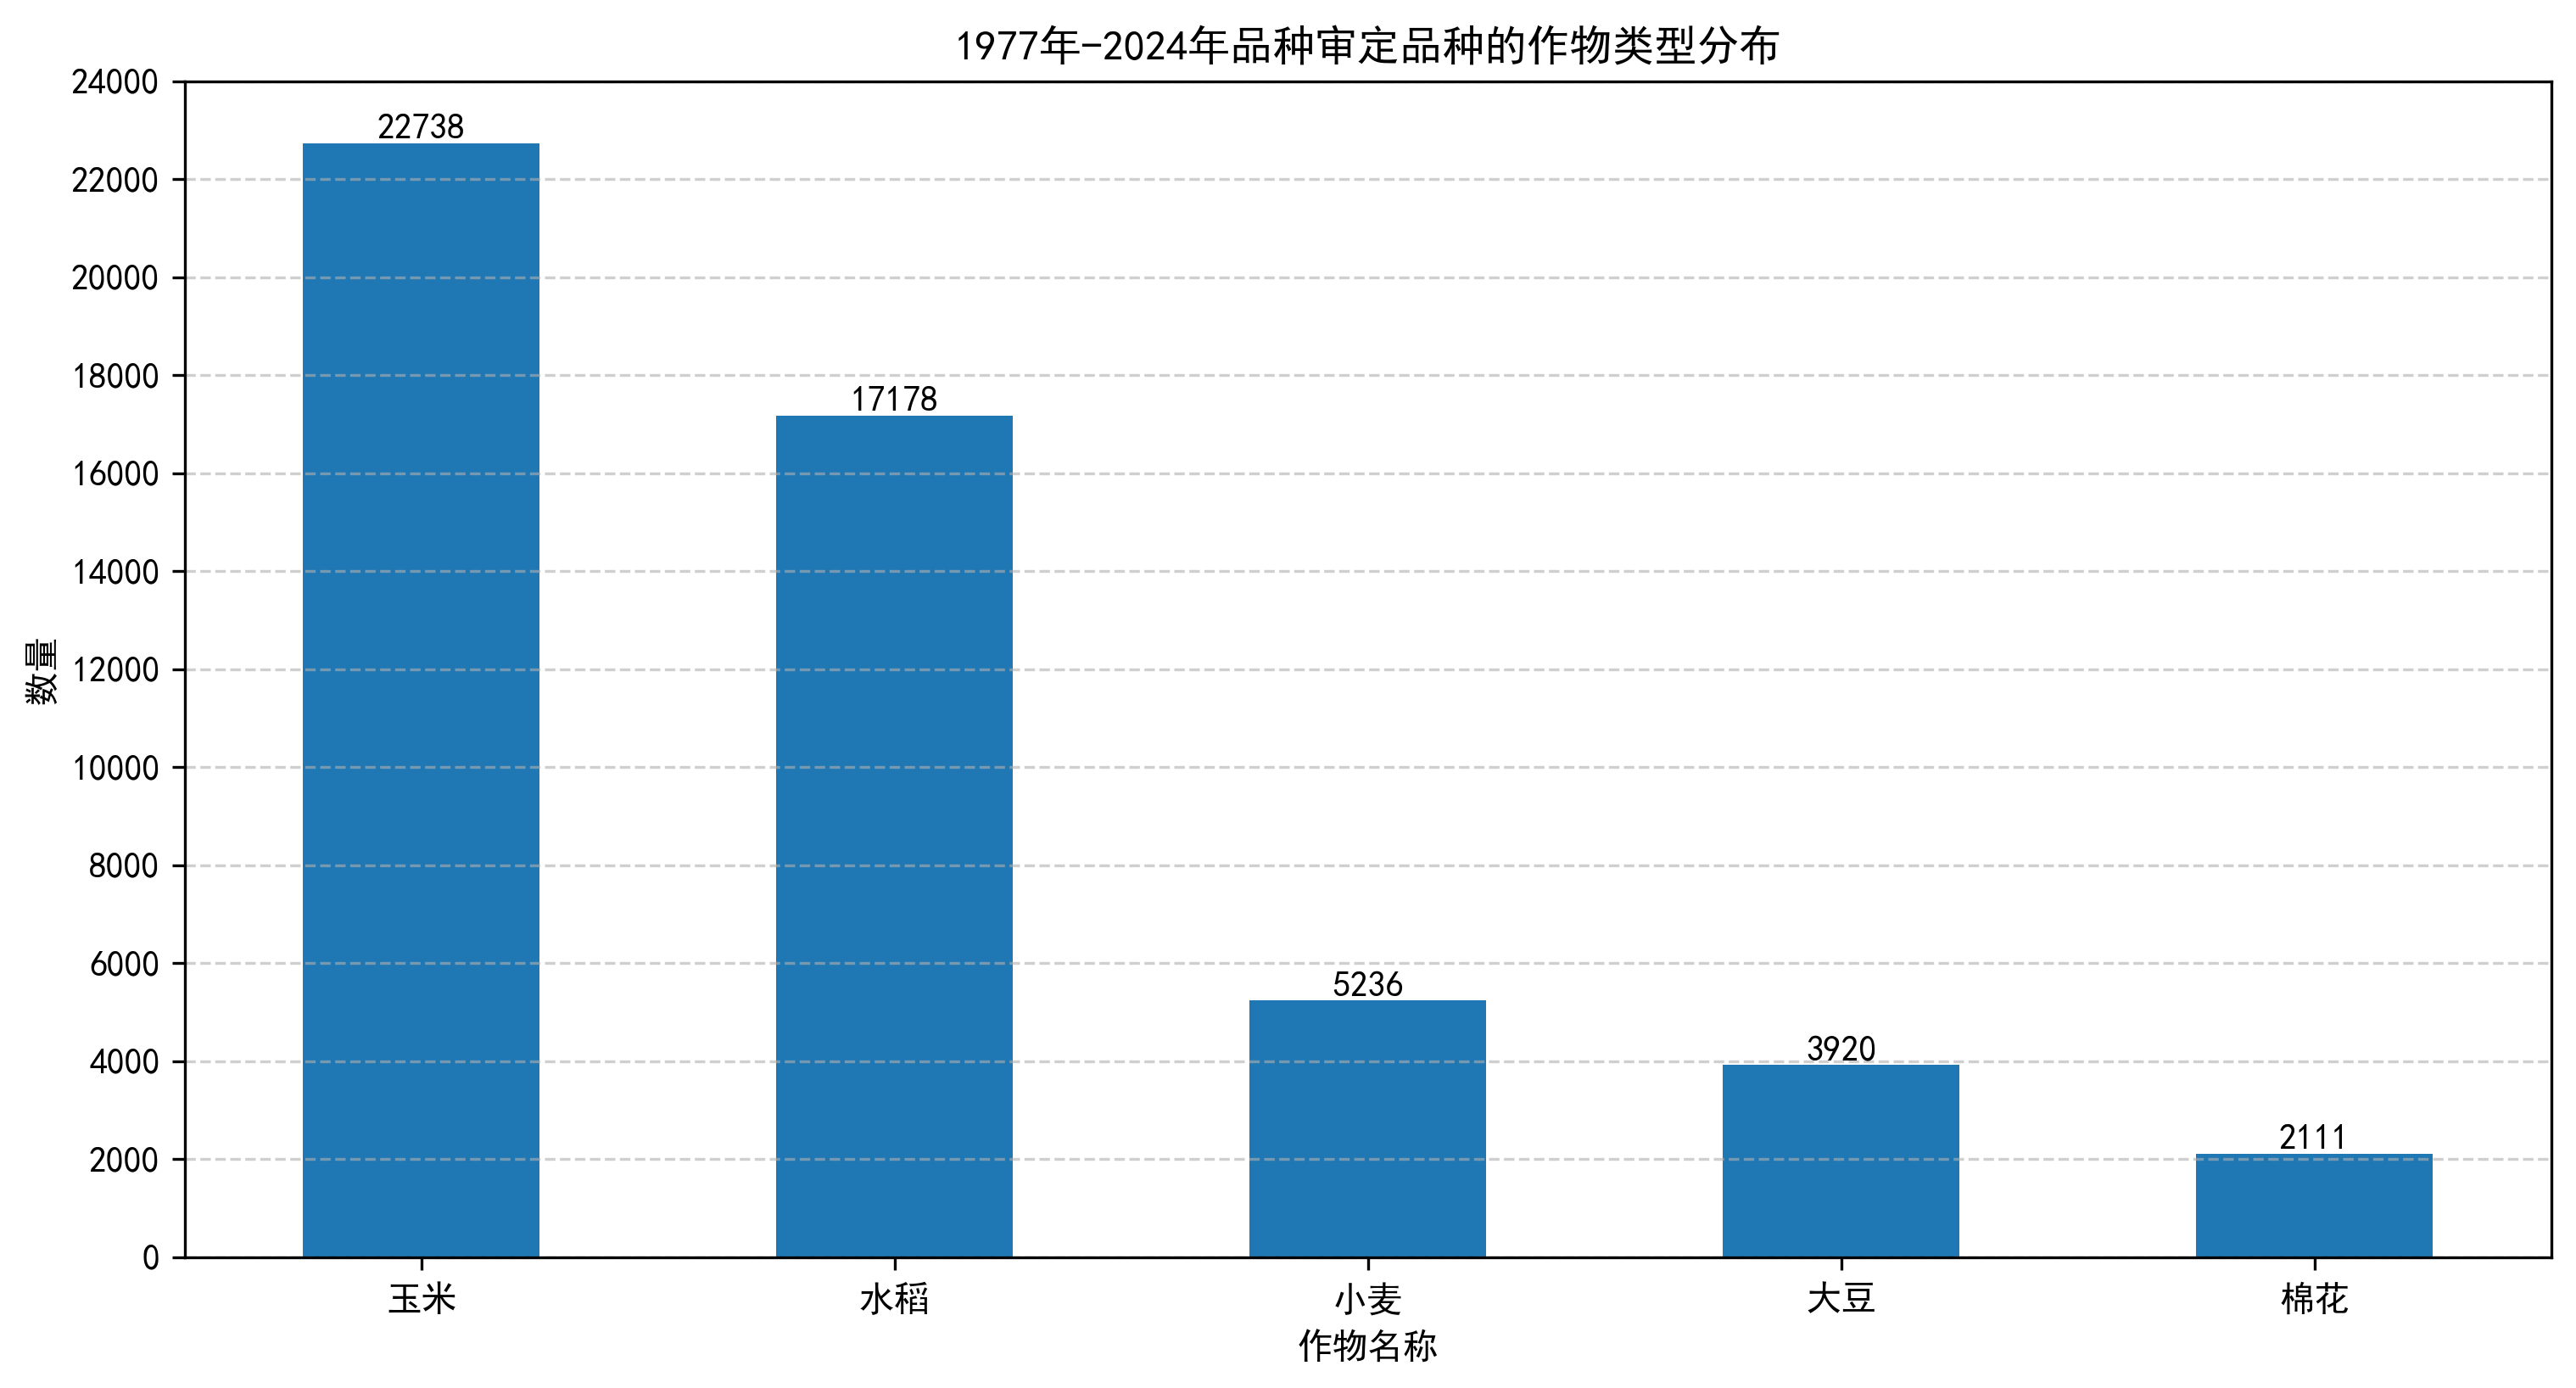

In [10]:
# 作物分布柱状图
plt.figure(figsize=(12,6),dpi=300)

# 作柱状图
df['cropname'].value_counts().plot.bar()

bars=df['cropname'].value_counts().plot.bar()

plt.title("1977年-2024年品种审定品种的作物类型分布")
plt.xlabel("作物名称")
plt.ylabel("数量")

# 让x轴标签水平显示
plt.xticks(rotation=0)

# 设置y轴范围和步长
plt.yticks(rotation=0,ticks=range(0,26000,2000))

# 添加y轴虚线
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 添加具体柱状数值
plt.bar_label(bars.containers[0], fontsize=10)

# 保存图片
plt.savefig('作物分布柱状图',dpi=300,bbox_inches='tight')

plt.show()

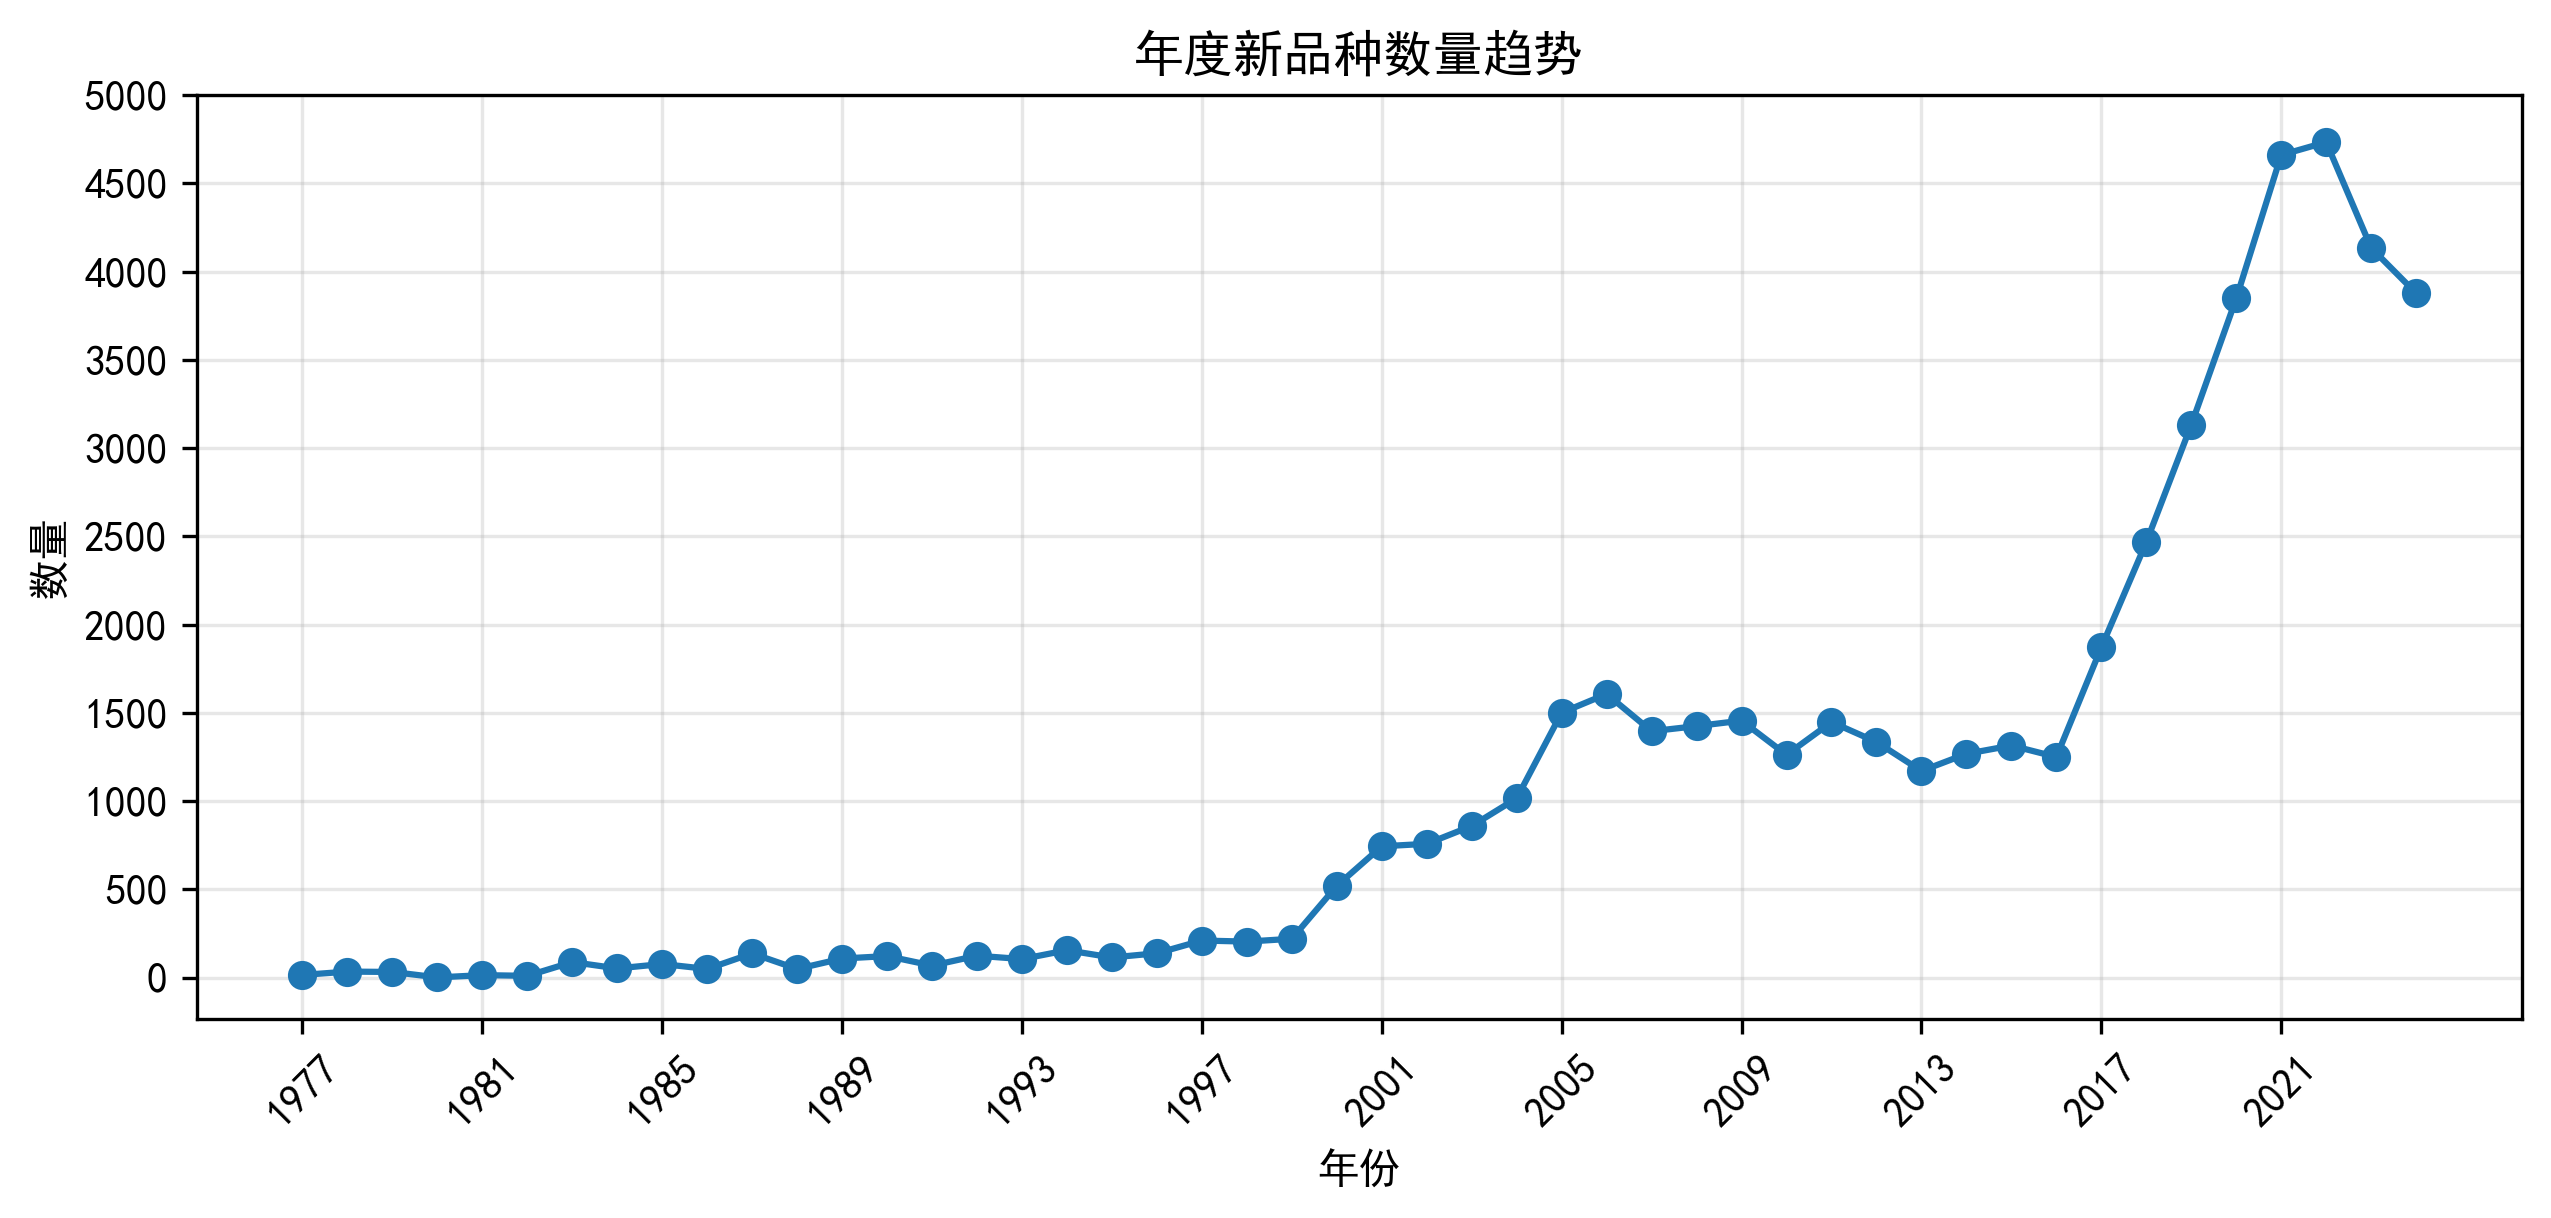

In [18]:
# 年度新品种数量趋势

year_count = df['judgementyear'].value_counts().sort_index()

plt.figure(figsize=(10,4),dpi=300)
plt.plot(year_count.index, year_count.values, marker='o')
plt.title("年度新品种数量趋势")
plt.xlabel("年份")
plt.ylabel("数量")
plt.grid(True, alpha=0.3)

plt.savefig("年度新品种数量趋势.png", dpi=300,bbox_inches='tight')

plt.xticks(ticks=range(1977,2025,4))
plt.xticks(rotation=45)

plt.yticks(ticks=range(0,5500,500))

# for x, y in zip(year_count.index, year_count.values):
#     plt.text(x, y, str(y), ha='center', va='bottom', fontsize=8)

plt.show()

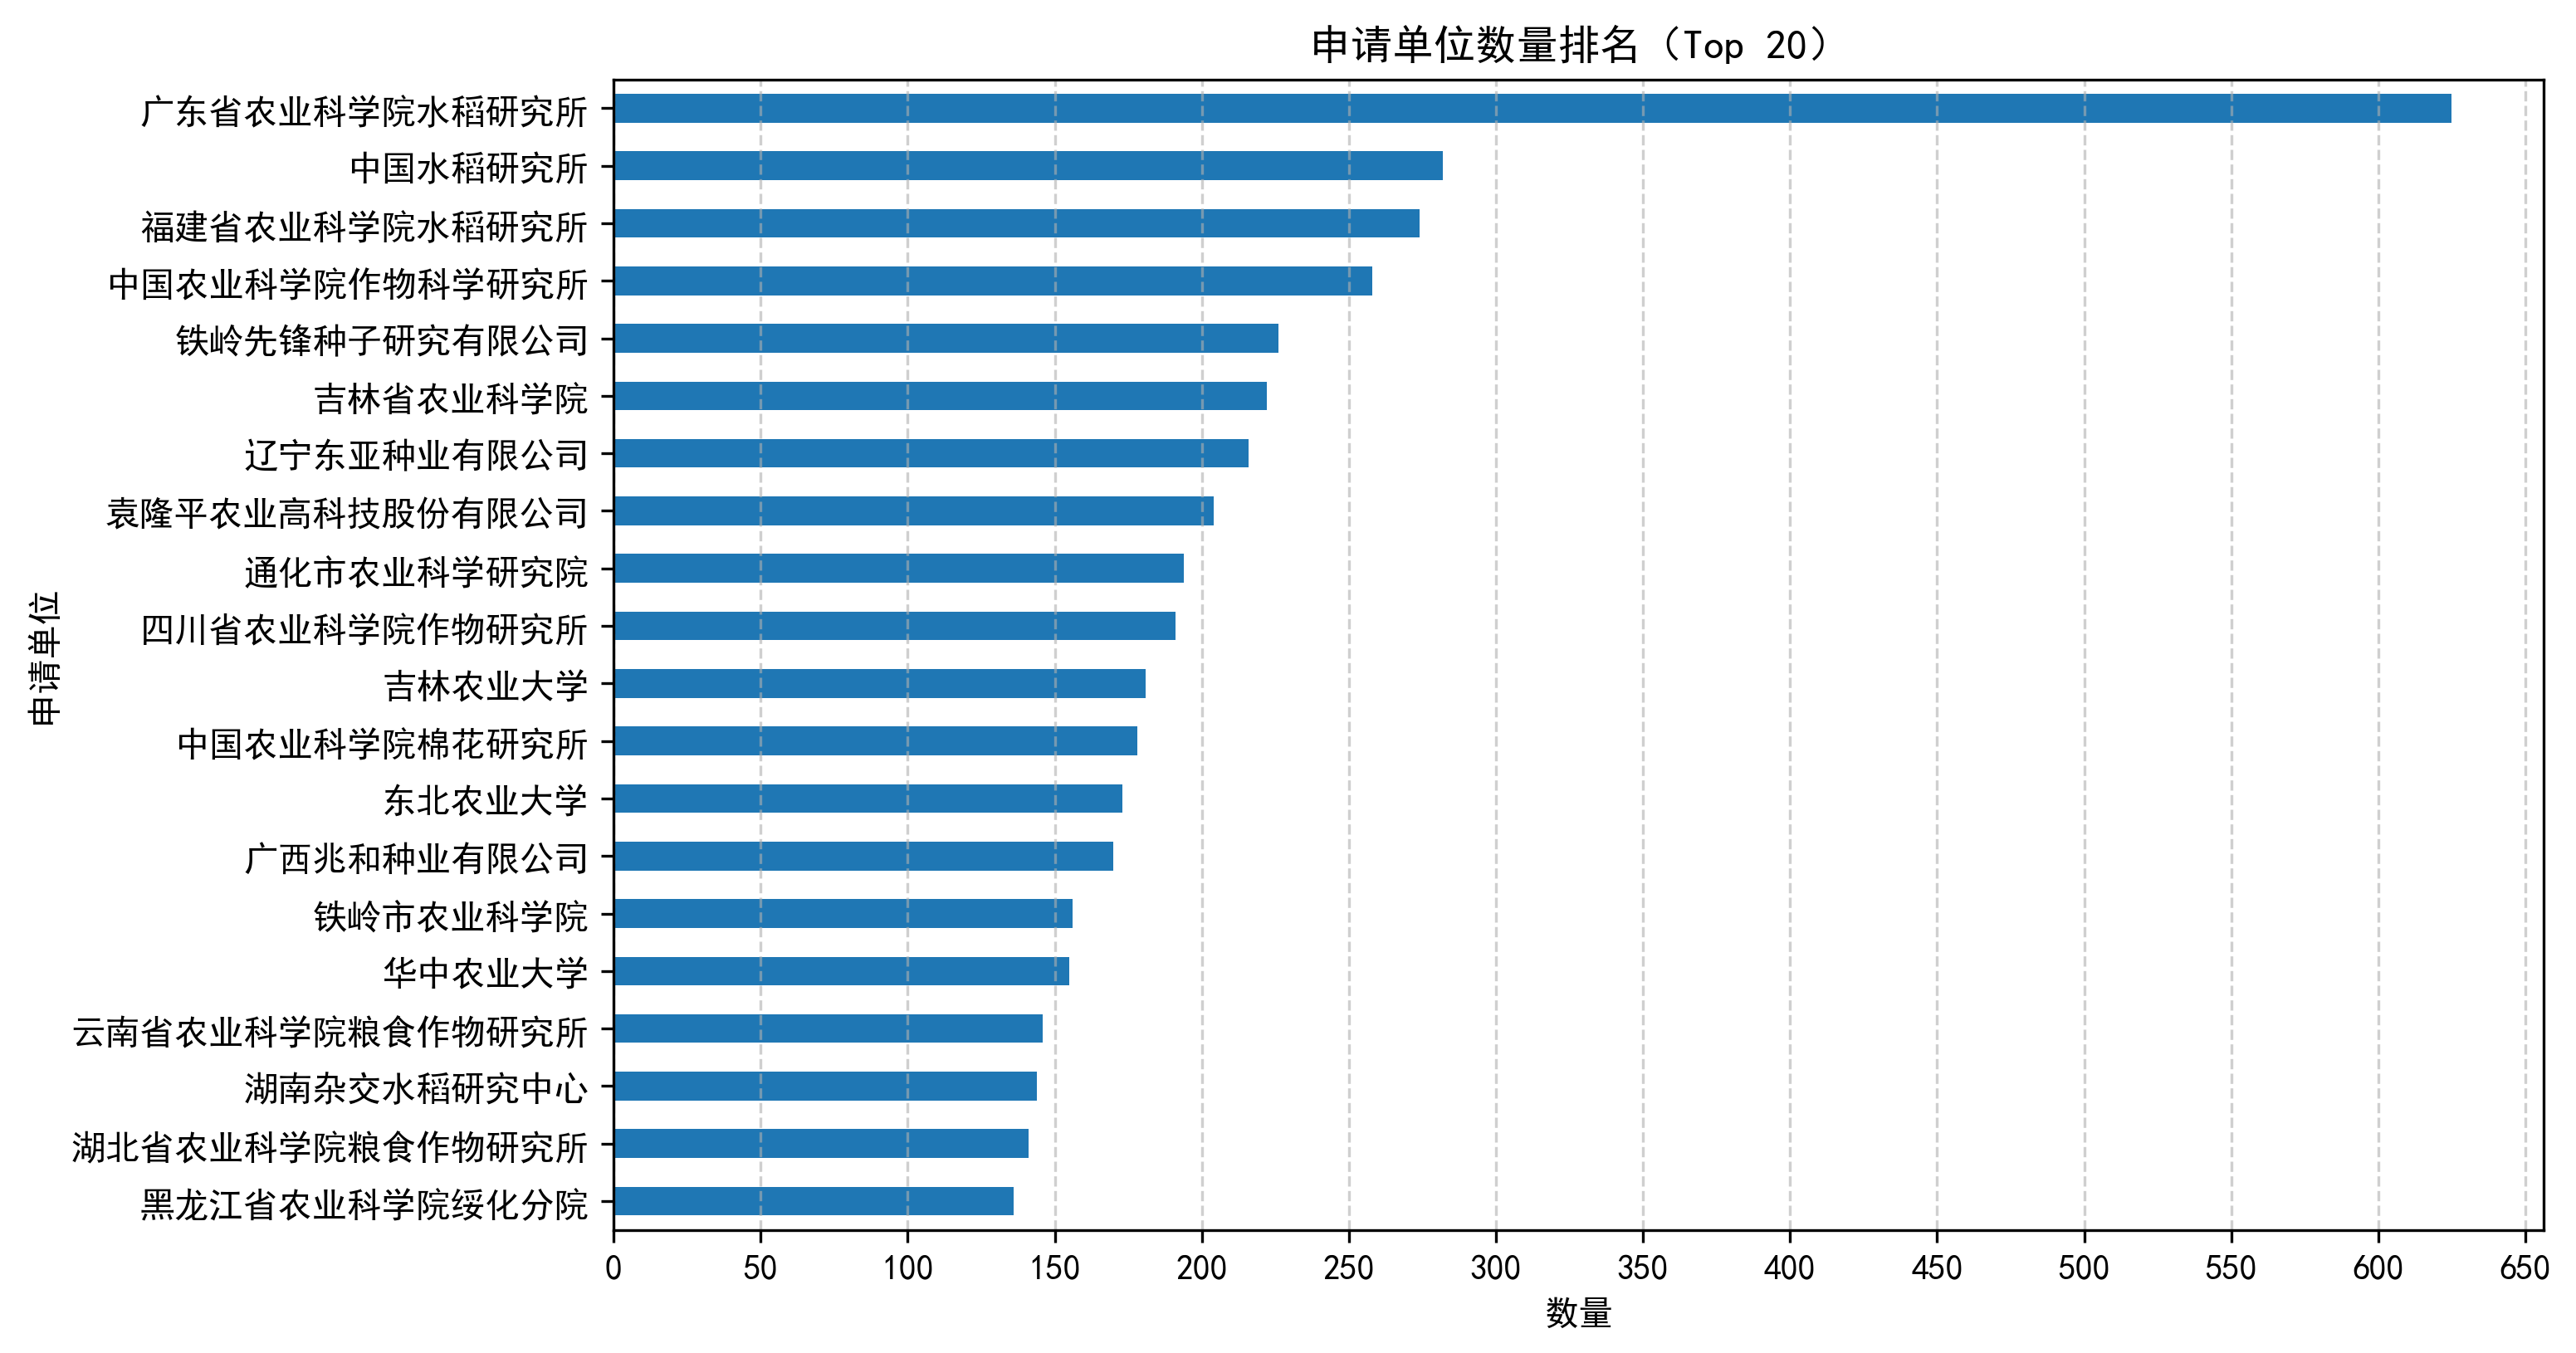

In [33]:
# 申请单位排名Top20

# 将多个申请者单位拆开
df_expanded = df.assign(applycompany=df['applycompany'].str.split('、')).explode('applycompany')

# 去除空格
df_expanded['applycompany'] = df_expanded['applycompany'].str.strip()

# 去掉空值
df_expanded = df_expanded[df_expanded['applycompany'].notna() & (df_expanded['applycompany'] != '')]

apply_top = df_expanded['applycompany'].value_counts().head(20)

plt.figure(figsize=(10,6),dpi=300)

# plot(kind='barh')表示画水平柱状图
apply_top.plot(kind='barh')

plt.title("申请单位数量排名（Top 20）")
plt.xlabel("数量")
plt.ylabel("申请单位")
plt.xticks(ticks=range(0,700,50))
plt.grid(axis='x',linestyle='--', alpha=0.6)

# plt.gca() 获取当前坐标轴对象，invert_yaxis()将y轴上下翻转
# 因为水平柱状图默认是从下到上画的，为了让排名第一显示在顶部，需要翻转y轴
plt.gca().invert_yaxis()

plt.savefig("top20_applycompany_units.png", dpi=300,bbox_inches='tight')

plt.show()

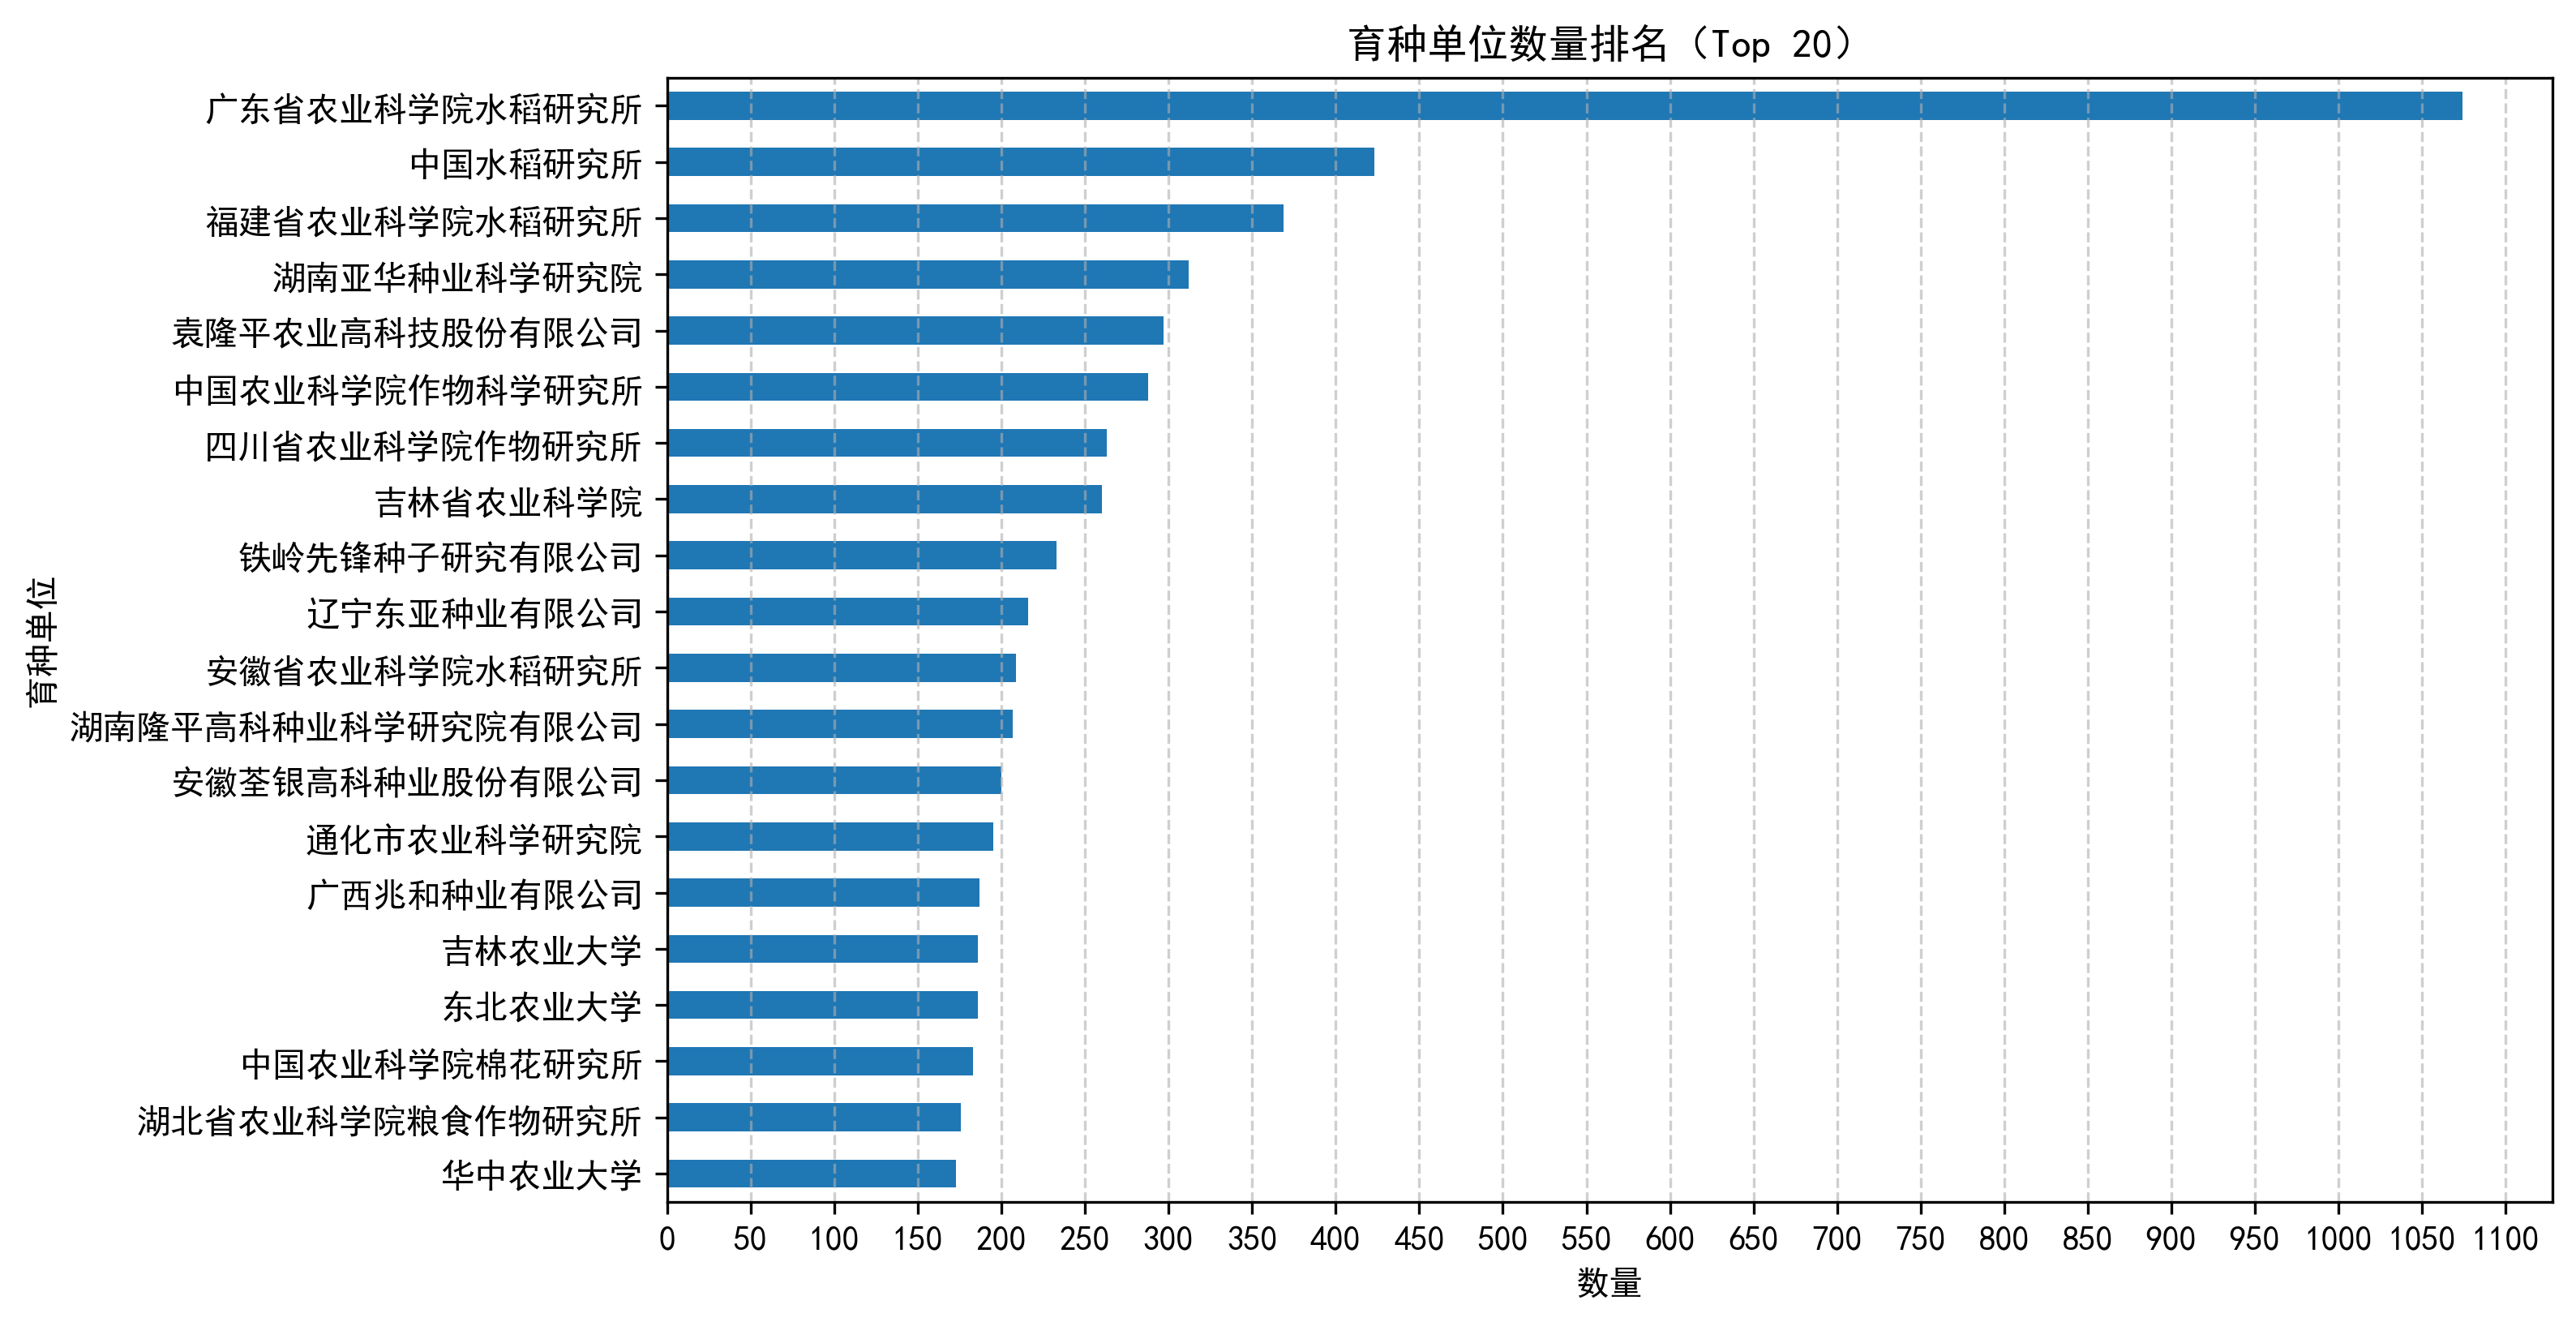

In [27]:
# 育种单位排名Top20
df_expanded = df.assign(breedingcompany=df['breedingcompany'].str.split('、')).explode('breedingcompany')

# 去除空格
df_expanded['breedingcompany'] = (
    df_expanded['breedingcompany']
    .str.strip()
)

# 去掉空值
df_expanded = df_expanded[df_expanded['breedingcompany'].notna() & (df_expanded['breedingcompany'] != '')]

apply_top = df_expanded['breedingcompany'].value_counts().head(20)

plt.figure(figsize=(10,6),dpi=300)

apply_top.plot(kind='barh')

plt.title("育种单位数量排名（Top 20）")
plt.xlabel("数量")
plt.ylabel("育种单位")
plt.xticks(ticks=range(0,1150,50))
plt.grid(axis='x',linestyle='--',alpha=0.6)

plt.gca().invert_yaxis()

plt.savefig("top20_breeding_units.png", dpi=300,bbox_inches='tight')

plt.show()

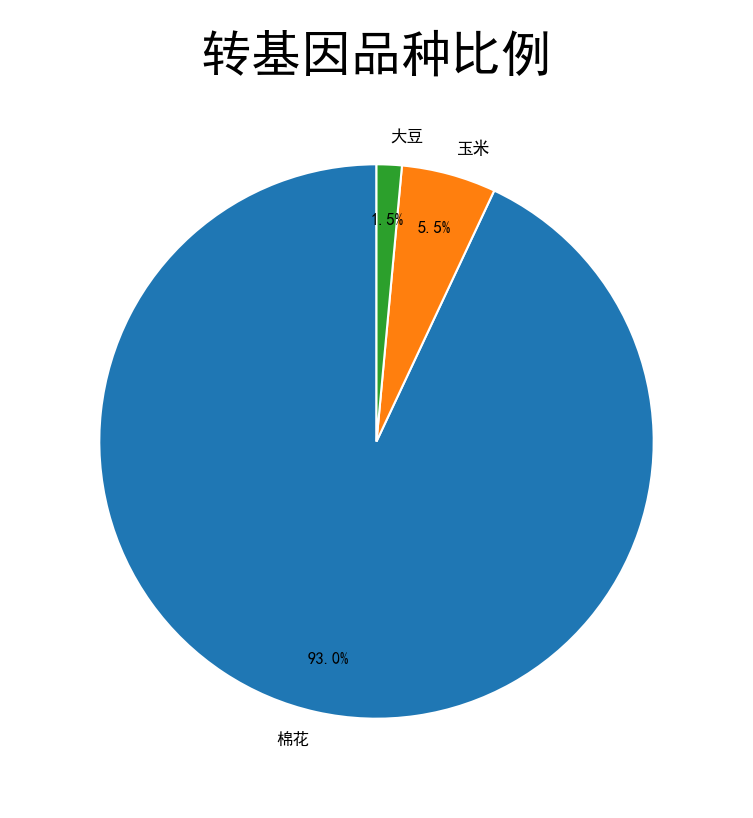

In [35]:
# 转基因品种比例饼图
plt.figure(figsize=(3,3),dpi=300)

df_zhuanjiyin['cropname'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,
    wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'},
    textprops={'fontsize': 4} 
)
plt.title("转基因品种比例")
plt.ylabel("")

plt.savefig('转基因比例饼图.png',dpi=300,bbox_inches='tight')
plt.show()

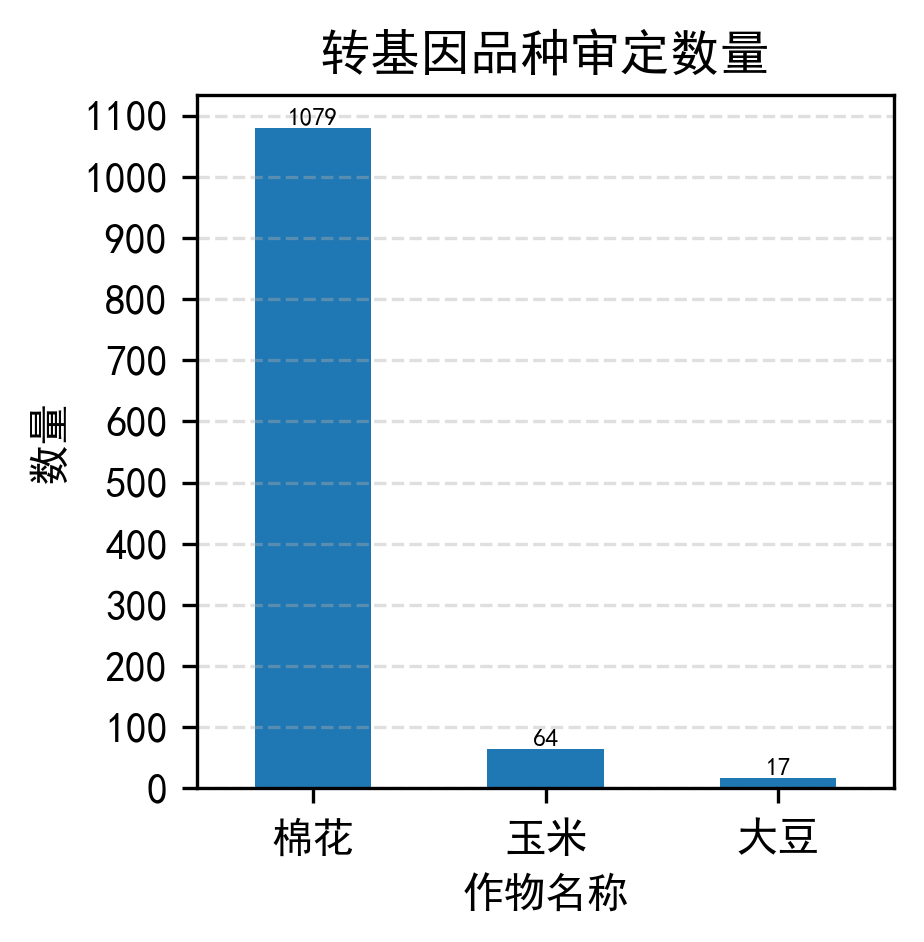

In [45]:
plt.figure(figsize=(3,3),dpi=300)

bars=df_zhuanjiyin['cropname'].value_counts().plot.bar()

plt.title("转基因品种审定数量")
plt.xlabel("作物名称")
plt.xticks(rotation=0)
plt.yticks(rotation=0,ticks=range(0,1200,100))
plt.bar_label(bars.containers[0], fontsize=6)
plt.grid(axis='y',linestyle='--',alpha=0.4)
plt.ylabel("数量")

plt.savefig('转基因比例柱状图.png',dpi=300,bbox_inches='tight')
plt.show()

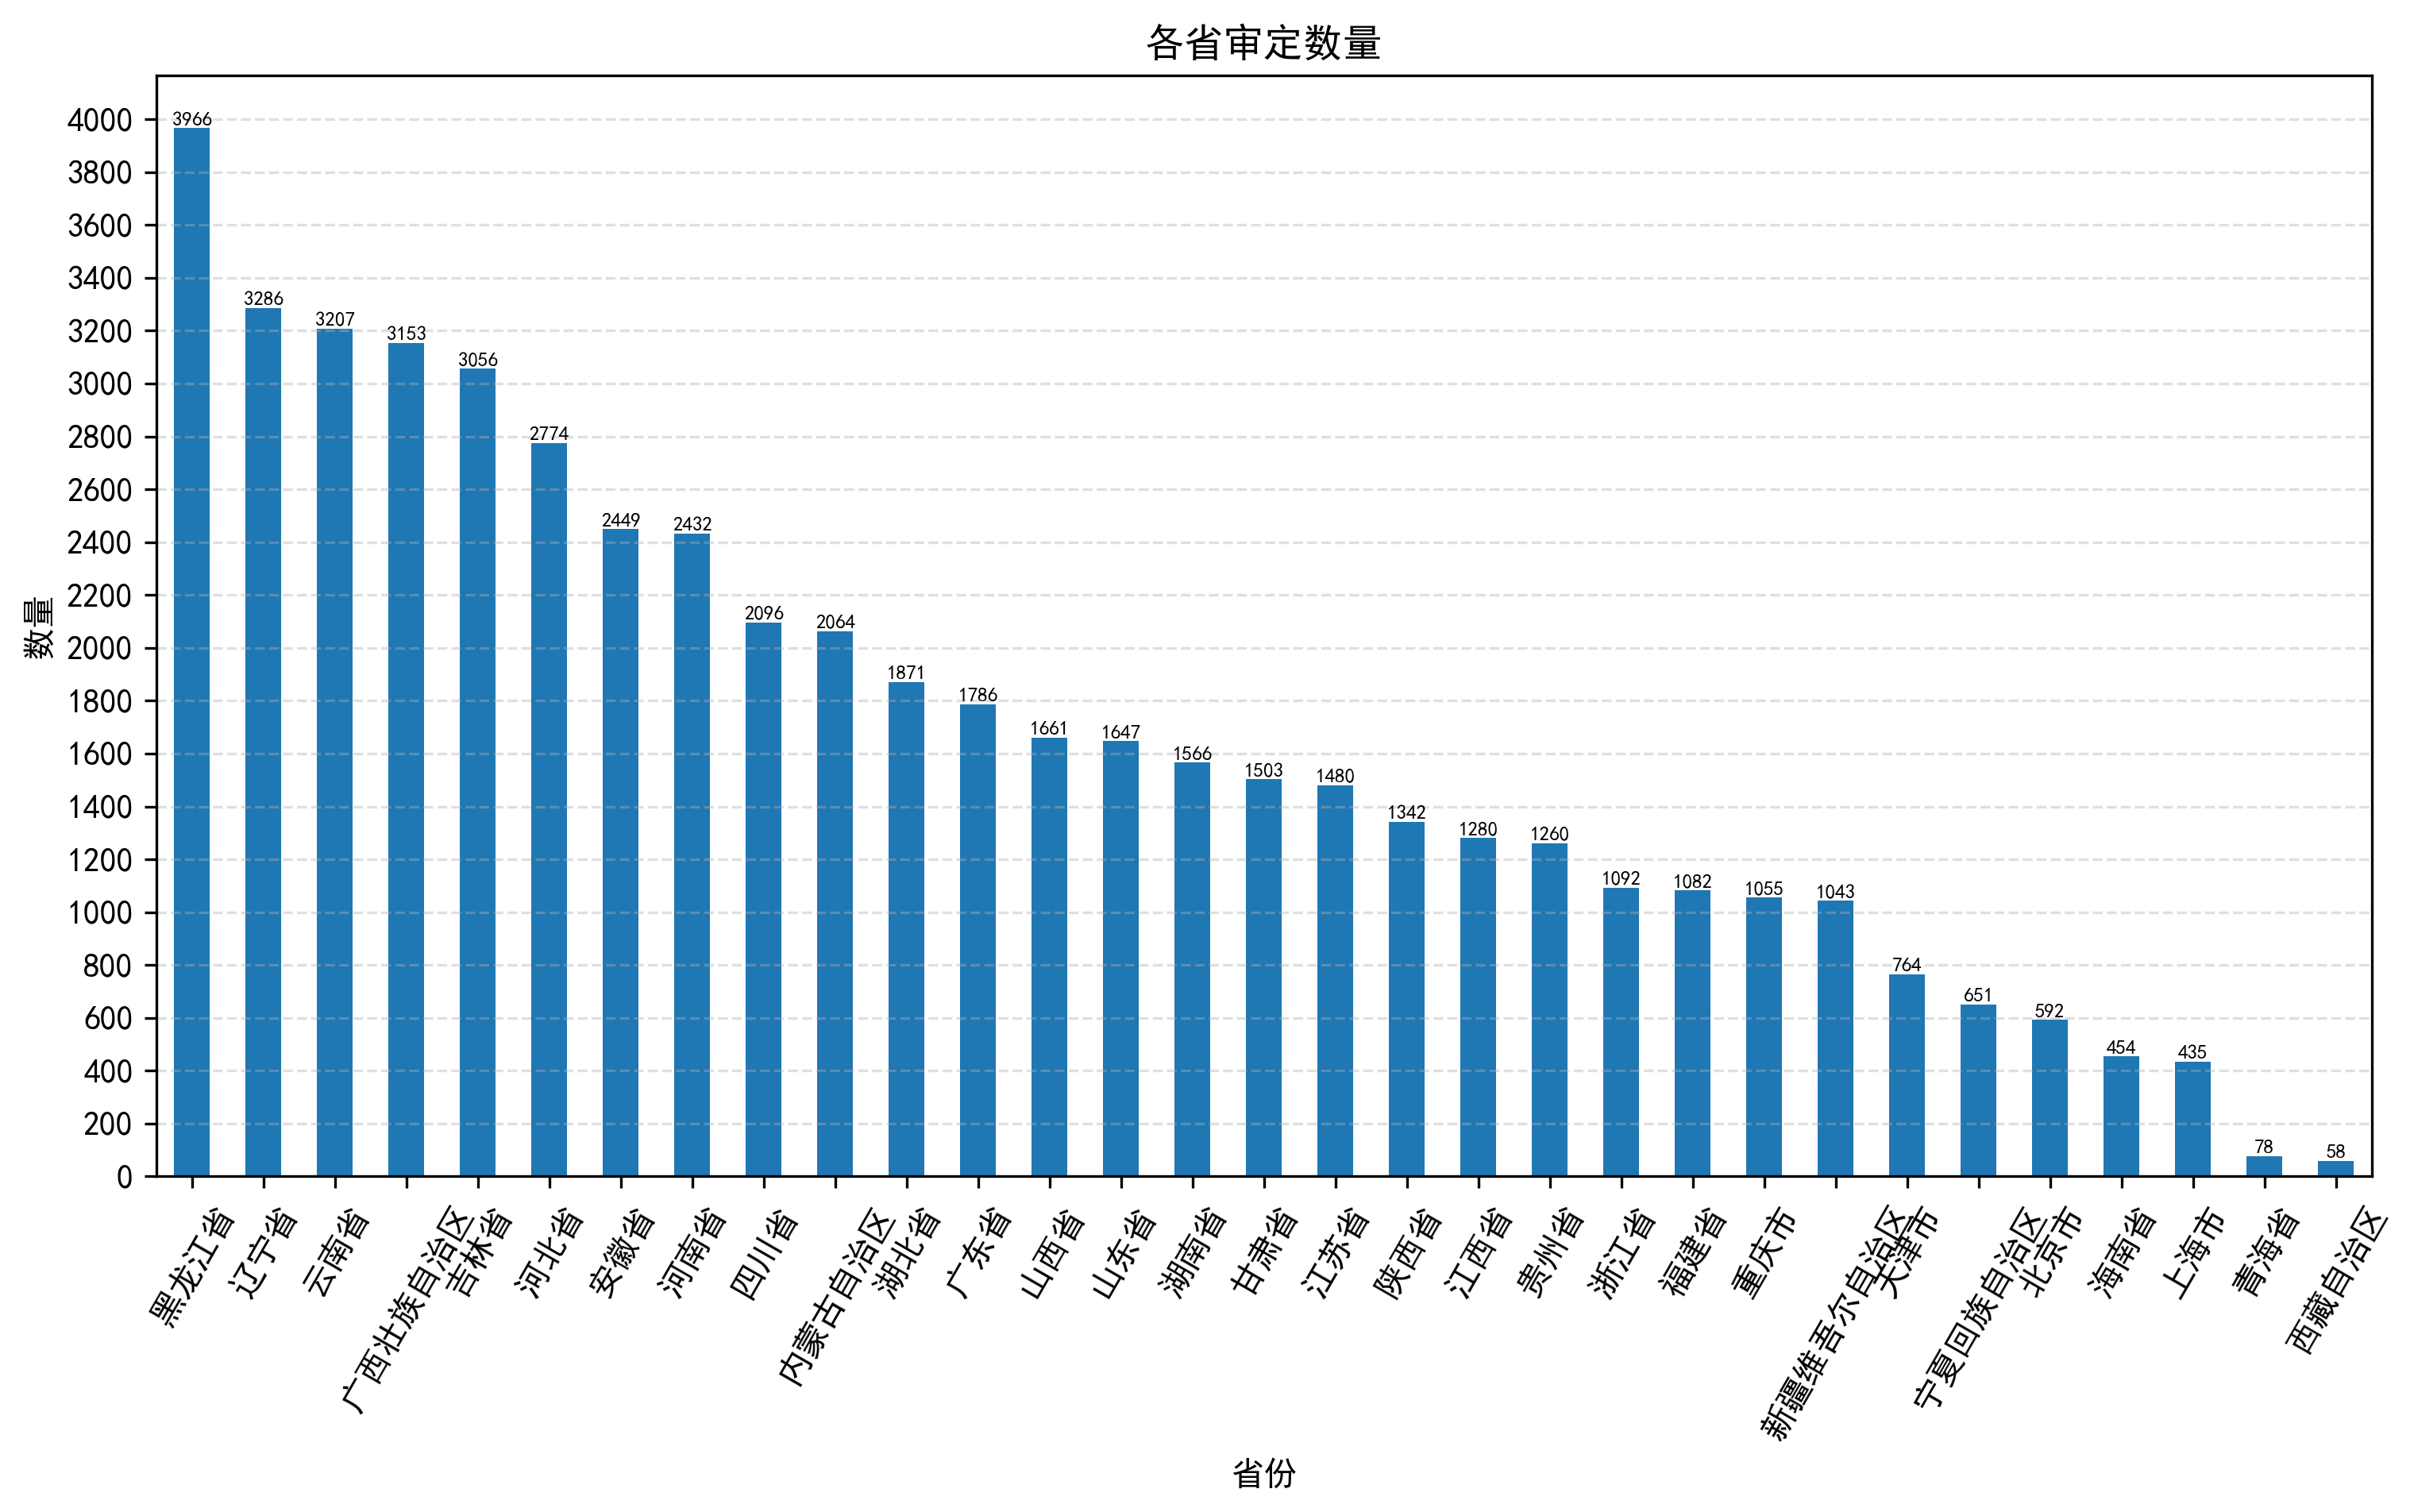

In [50]:
# 各省审定数量排名

region_count = df['judgementregion'].value_counts()


plt.figure(figsize=(12,6),dpi=300)
region_count.plot(kind='bar')

bars=df['judgementregion'].value_counts().plot.bar()

plt.title("各省审定数量")
plt.xlabel("省份")
plt.ylabel("数量")

plt.xticks(rotation=60)
plt.yticks(rotation=0,ticks=range(0,4200,200))
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.bar_label(bars.containers[0], fontsize=6)
plt.savefig("省份排名.png", dpi=300,bbox_inches='tight')

plt.show()

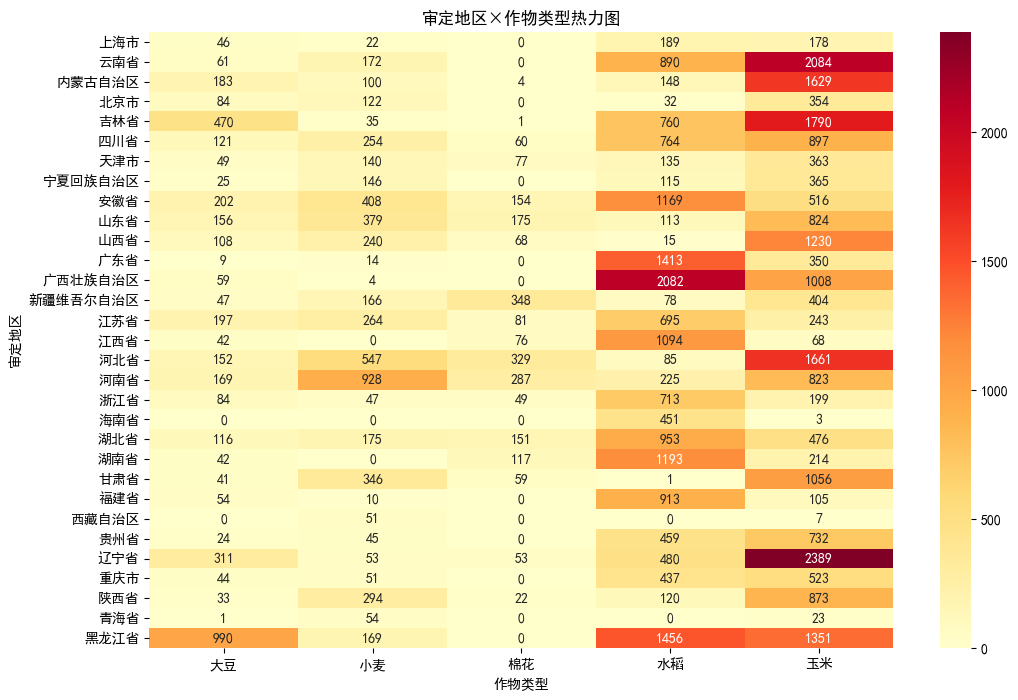

In [51]:
# 审定地区×作物类型 热力图

pivot = df.pivot_table(
    index="judgementregion",
    columns="cropname",
    values="varietyname",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(12,8))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd")
plt.title("审定地区×作物类型热力图")
plt.xlabel("作物类型")
plt.ylabel("审定地区")


plt.savefig("审定地区×作物类型.png", dpi=300,bbox_inches='tight')
plt.show()


In [60]:
!pip install pyecharts

     ------------------------------------- 153.9/153.9 kB 74.1 kB/s eta 0:00:00
     --------------------------------------- 76.1/76.1 kB 95.7 kB/s eta 0:00:00



[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
from pyecharts.charts import Map
from pyecharts import options as opts

region_count = df['judgementregion'].value_counts().reset_index()
region_count.columns = ["地区", "数量"]

m = (
    Map()
    .add("审定数量", [tuple(x) for x in region_count.values], "china")
    .set_global_opts(
        title_opts=opts.TitleOpts(title="各省审定数量地图"),
        visualmap_opts=opts.VisualMapOpts(max_=region_count["数量"].max())
    )
)

m.render("china_map.html")
m

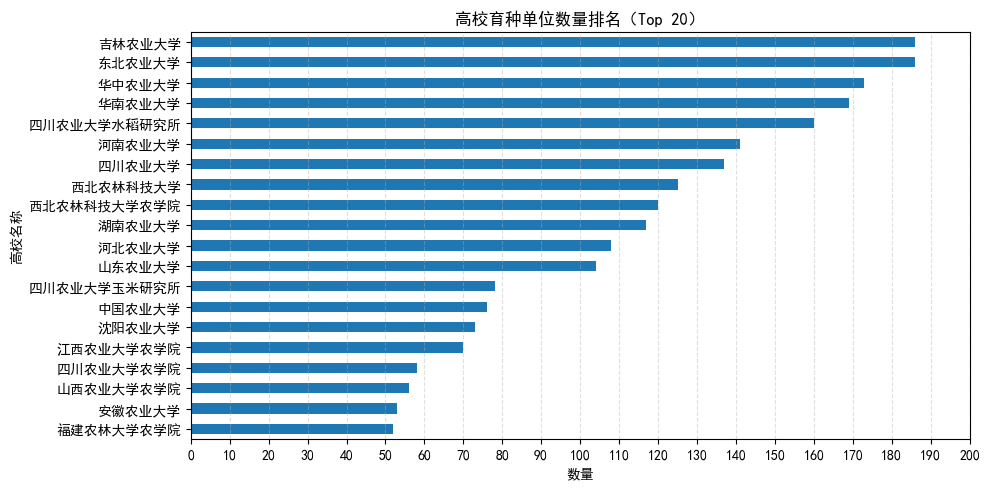

In [53]:
name_map = {
    "国家植物航天育种工程技术研究中心（华南农业大学）": "华南农业大学",
    "华南农业大学农学院": "华南农业大学"}

# 拆分育种单位
df_expanded = df.assign(breedingcompany=df['breedingcompany'].str.split('、')).explode('breedingcompany')

# 删去空格
df_expanded['breedingcompany'] = df_expanded['breedingcompany'].str.strip()

df_expanded['breedingcompany'] = df_expanded['breedingcompany'].replace(name_map)

df_univ = df_expanded[
    df_expanded['breedingcompany']
    .str.contains("大学",na=False)
]

top_univ = df_univ['breedingcompany'].value_counts().head(20)

plt.figure(figsize=(10,5))
top_univ.plot(kind='barh')
plt.title("高校育种单位数量排名（Top 20）")

plt.xlabel("数量")
plt.ylabel("高校名称")
plt.xticks(ticks=range(0,210,10))
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("top20_universities.png", dpi=300, bbox_inches='tight')
plt.show()

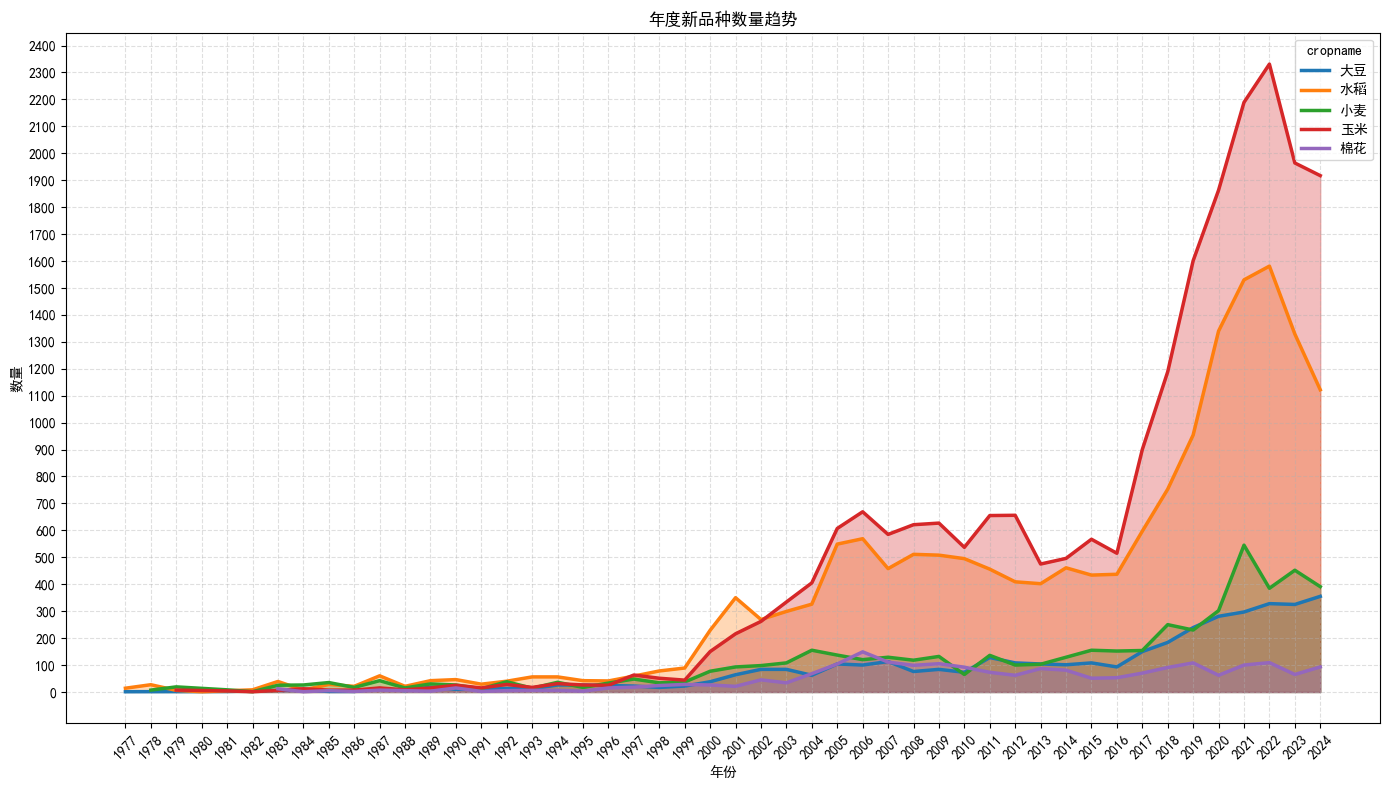

In [61]:
year_crop_count = df.groupby(['judgementyear', 'cropname']).size().reset_index(name='count')

plt.figure(figsize=(14,8))
sns.lineplot(x='judgementyear',
             y='count',
             data=year_crop_count,
             hue='cropname',
             palette='tab10',
             linewidth=2.5,
             # fillstyle='full',marker='o'
            )

crops = year_crop_count['cropname'].unique()

# 获取当前图的颜色循环
colors = plt.gca().get_lines()

# 给每条线添加填充
for crop, line in zip(crops, colors):
    crop_data = year_crop_count[year_crop_count['cropname'] == crop]
    plt.fill_between(
        crop_data['judgementyear'],
        crop_data['count'],
        color=line.get_color(),
        alpha=0.3   # 透明度
    )


plt.xticks(ticks=range(year_crop_count['judgementyear'].min(),
                       year_crop_count['judgementyear'].max()+1,
                       1))

plt.title("年度新品种数量趋势")
plt.xlabel("年份")
plt.ylabel("数量")
plt.xticks(rotation=45)
plt.yticks(ticks=range(0,2500,100))
plt.tight_layout()
plt.grid(True,linestyle='--',alpha=0.4)

plt.savefig('年度新品种数量趋势.png',dpi=300,bbox_inches='tight')
plt.show()